In [1]:
import pandas as pd

In [2]:
fruits = pd.read_csv('../Data/fruits.csv')
fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


In [3]:
fruits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   length  49 non-null     float64
 1   weight  49 non-null     float64
 2   name    49 non-null     object 
dtypes: float64(2), object(1)
memory usage: 1.3+ KB


In [4]:
# 사과 정보 불러오기
apple = fruits[:35]
apple.tail()

,length,weight,name
30,38.5,920.0,apple
31,38.5,955.0,apple
32,39.5,925.0,apple
33,41.0,975.0,apple
34,41.0,950.0,apple


##### apple 산포도

In [5]:
import matplotlib.pyplot as plt

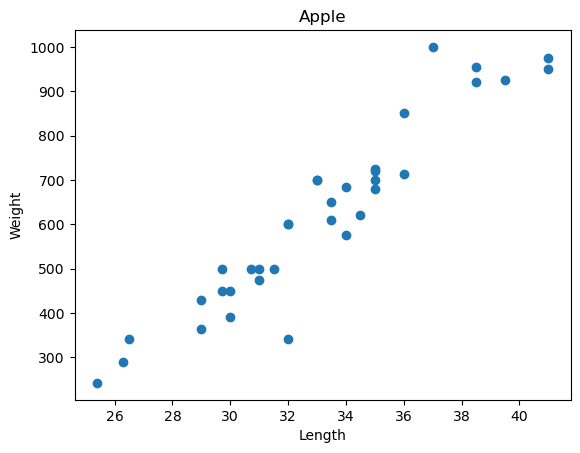

In [8]:
plt.scatter(
    apple['length'],
    apple.weight # 둘다 됨
)

plt.title('Apple')
plt.xlabel('Length')
plt.ylabel('Weight')

plt.show()

In [9]:
# berry 정보 불러오기
berry = fruits[35:]
berry.head()

,length,weight,name
35,9.8,6.7,berry
36,10.5,7.5,berry
37,10.6,7.0,berry
38,11.0,9.7,berry
39,11.2,9.8,berry


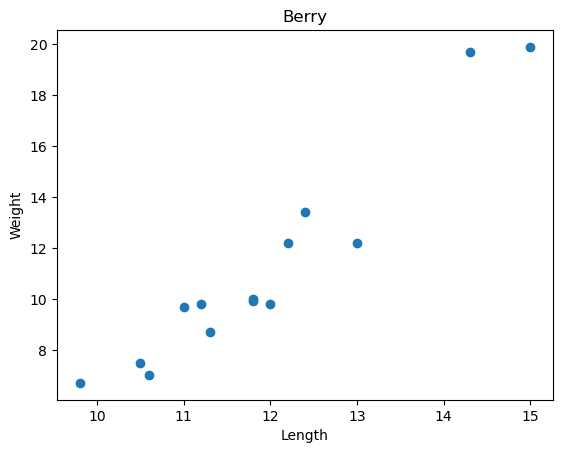

In [10]:
plt.scatter(
    berry.length,
    berry.weight
)

plt.title('Berry')
plt.xlabel('Length')
plt.ylabel('Weight')

plt.show()

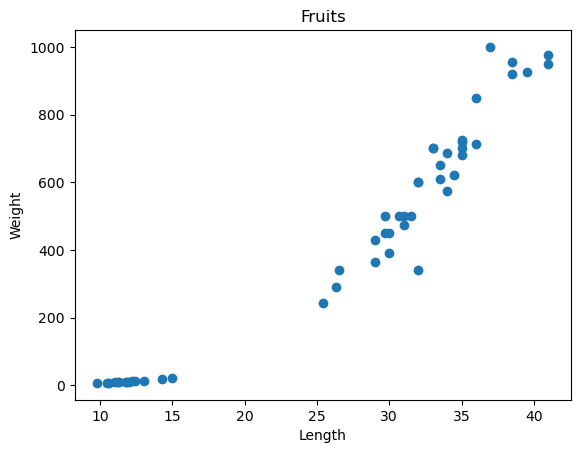

In [11]:
# fruits 로 산포도
plt.scatter(
    fruits.length,
    fruits.weight
)

plt.title('Fruits')
plt.xlabel('Length')
plt.ylabel('Weight')

plt.show()

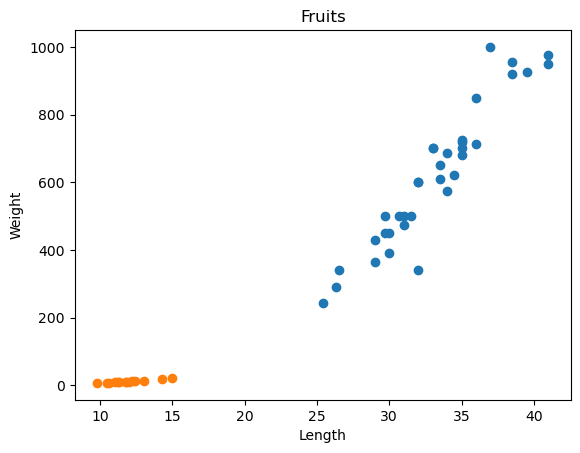

In [16]:
# 2개의 Dataset 를 산포도로 한꺼번에 비교하기
plt.scatter(
    apple.length,
    apple.weight
)

plt.scatter(
    berry.length,
    berry.weight
)

plt.xlabel('Length')
plt.ylabel('Weight')
plt.title('Fruits')

plt.show()

##### 머신러닝을 위한 데이터 준비
- Feature Data 와 Target Data 분리

In [18]:
# Feature Data
fruitsData = fruits[
    ['length', 'weight']
]
fruitsData.head()

,length,weight
0,25.4,242.0
1,26.3,290.0
2,26.5,340.0
3,29.0,363.0
4,29.0,430.0


In [27]:
fruitsData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   length  49 non-null     float64
 1   weight  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [28]:
# Target Data
fruitsTarget = fruits['name']
fruitsTarget.head()

0    apple
1    apple
2    apple
3    apple
4    apple
Name: name, dtype: object

In [29]:
fruitsTarget.info()

<class 'pandas.core.series.Series'>
RangeIndex: 49 entries, 0 to 48
Series name: name
Non-Null Count  Dtype 
--------------  ----- 
49 non-null     object
dtypes: object(1)
memory usage: 524.0+ bytes


#### 최근접이웃(kNN : k Nearest Neighbors) 분류 알고리즘
 - 주변 k 개 값의 결과를 보고 다수의 결과값으로 추측.

In [30]:
from sklearn.neighbors import KNeighborsClassifier

In [31]:
# Model 생성
kn = KNeighborsClassifier()  # default : 5, HyperParameter 조정 : n_neighbors = 3

In [32]:
# 학습시키기
kn.fit(fruitsData, fruitsTarget)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [33]:
# 정확도
kn.score(fruitsData, fruitsTarget)

1.0

In [36]:
# 예측해보기
# 길이가 30이고 무게가 600인 것은 무엇인가?
kn.predict([
    [30, 600]
])

c:\Users\tjoeun\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['apple'], dtype=object)

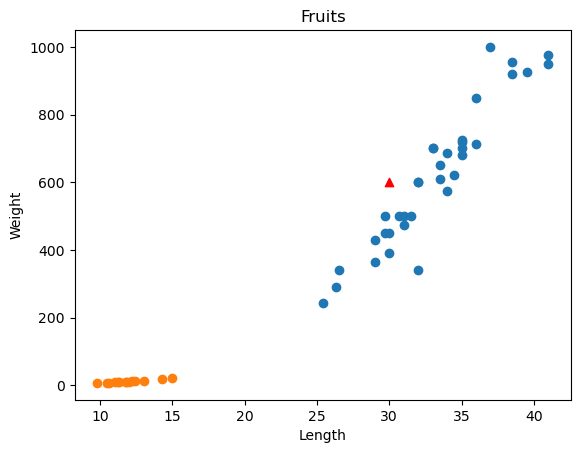

In [40]:
# 산포도로 예측 범위 확인하기
plt.scatter(
    apple.length,
    apple.weight
)

plt.scatter(
    berry.length,
    berry.weight
)

plt.scatter(30, 600, c='red', marker='^')

plt.xlabel('Length')
plt.ylabel('Weight')
plt.title('Fruits')

plt.show()